### Ex. 1. 

Scrieţi un program în Python care să preia ca input un fişier .csv cu o listă oarecare şi să aibă ca output un număr
predeterminat de elemente din acea listă, fără repetiţie. Aplicaţi pe lista studenţilor din grupa dumneavoastră care nu
au prezentat încă o temă.

Notă: Pentru generarea unui eşantion aleator se poate apela funcţia sample din modulul random sau funcţia random.choice cu argumentul replace=False din librăria Numpy.

In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import arviz

def random_sample(csv_path : str, count : int) :
  with open(csv_path) as f:
    reader = csv.reader(f)
    lines = list(reader)
    entries = [item for sublist in lines for item in sublist]
    return np.random.choice(entries, size=count, replace=False)




In [2]:
print(random_sample("elevi_neseriosi.csv", 3))

[' Popa Robert' ' Gruia the Potter' ' Croitoriu Alex Andra']


Ex. 2. Doi prieteni joacă următorul joc, după următoarele reguli: \
Pasul 1. Primul jucător aruncă cu o monedă. \
● Dacă pică stemă, cel de-al doilea trebuie să arunce cu zarul şi să-i dea primului o sumă egală z − 3 \$, unde z
este rezultatul aruncării cu zarul (a da o sumă negativă este echivalent cu a lua opusul acelei sume). Jocul
se încheie aici.\
● Dacă pică ban, atunci primul jucător trebuie să-i dea celui de-al doilea 0.5 \$. \
Pasul n. În caz că jocul nu s-a încheiat, se reia pasul 1.\
Astfel, jocul se opreşte la pasul corespunzător obţinerii stemei de către primul jucător.


a) Ce fel de distribuţie urmează N, numărul de paşi ai jocului? 


N urmează distribuția $P(N = x) = (1 - p) ^{x - 1} * p = 0.5 ^{x}$ -> Care se numește distribuția geometrică

b) Simulaţi în Python un astfel de joc. Variabilele care ne interesează sunt N şi suma totală S pe care cel de-al
doilea jucător trebuie să i-o dea primului.

In [3]:
rng = np.random.default_rng()
def game_run(probability : float = 0.5) :
  last_result = 0
  runs = 0
  while (last_result == 0) :
    runs += 1
    last_result = rng.binomial(n = 1, p = probability)
  z = np.random.randint(1, 7)
  return (runs, z - (runs - 1) * 0.5 - 3)





In [4]:
game_run()

(1, -2.0)

c) Prin simularea unui număr mare de astfel de jocuri, determinaţi cu aproximaţie media lui S şi reprezentaţi grafic
(printr-o histogramă) distribuţia acesteia.

In [5]:
def runs(probability : float = 0.5, count : int = 1000) :
  observed_Ns = []
  observed_Sums = []
  for i in range(count):
    n, s = game_run(probability)
    observed_Ns.append(n)
    observed_Sums.append(s)
  N_vals = list(set(observed_Ns))
  N_freqs = [observed_Ns.count(n) for n in N_vals]
  S_vals = list(set(observed_Sums))
  S_freqs = [observed_Sums.count(s) for s in S_vals]

  mean_S = np.mean(observed_Sums)

  fig, (ax_n, ax_s) = plt.subplots(1, 2, figsize=(12, 4))

  ax_n.bar(N_vals, N_freqs, alpha=0.7, color='lightgreen', edgecolor='black')
  ax_n.set_title("Distribution of Runs")

  ax_s.bar(S_vals, S_freqs, width = 0.5, alpha=0.7, color='lightblue', edgecolor='black')
  ax_s.axvline(mean_S, color='red', linestyle='--', label=f"mean S = {mean_S:.2f}")
  ax_s.set_title("Distribution of Sums")
  ax_s.legend()

  plt.tight_layout()
  plt.show()

  return mean_S

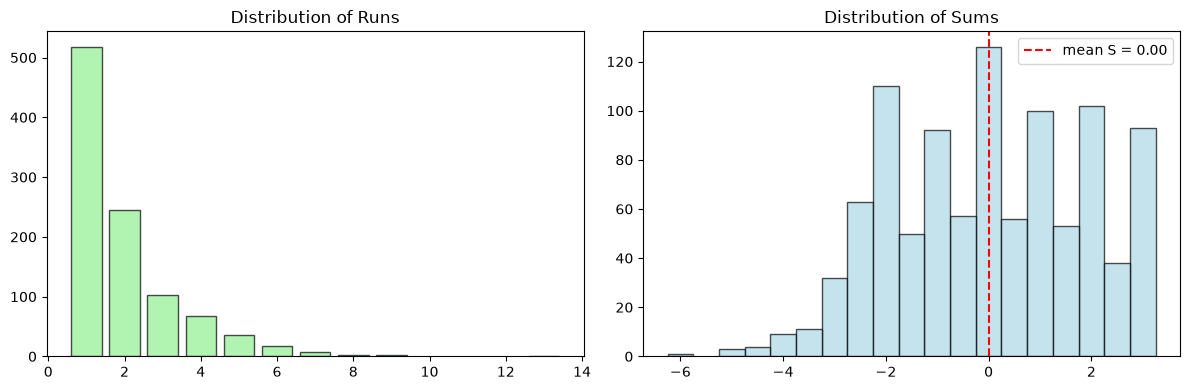

np.float64(0.003)

In [6]:
runs(0.5, 1000)

\begin{align*}
E(S) = E(z - 3 - 0.5 * (N - 1)) &= E(z) -  3 - E(N) * 0.5 + 0.5 \\
                          &= 3.5 - 3 - E(N) * 0.5 + 0.5 \\
                          &= 0.5 - E(N) * 0.5 + 0.5 \\
                          &= 0.5 - 1 / p * 0.5 + 0.5 \\
                          &= 0.5 * (1 - 1/p + 1) \\
                          &= 0.5 * (2p - 1) / p \\
                          &= 0.5 * (-0.5) / 0.5 \\
                          &= 0.5
\end{align*}

d) Ce se întâmplă dacă moneda este măsluită? Încercaţi să refaceţi pct. c) cu o probabilitate de apariţie a stemei
p = 0.3, respectiv p = 0.7.

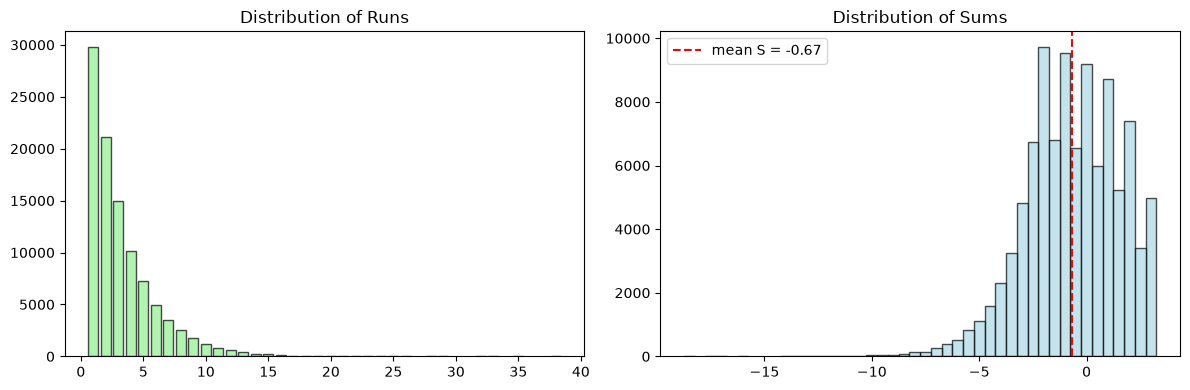

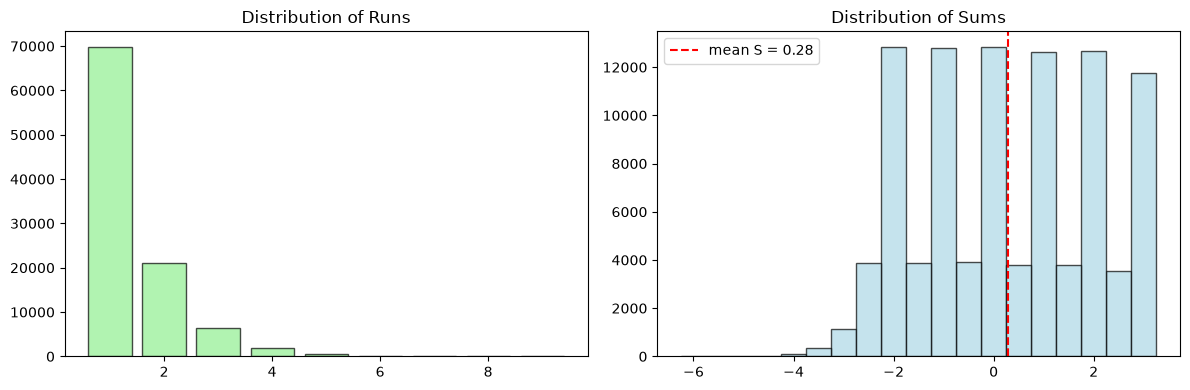

np.float64(0.284735)

In [ ]:
runs(0.3, 100000)
# mean_S = 0.5 * (-0.4) / 0.3 = -0.67777777
runs(0.7, 100000)
# mean_S = 0.5 * (0.4) / 0.7 = 0.28571428

Ex. 3. Într-o frizerie, trei frizeri îşi tund clienţii cu următoarele viteze medii: primul cu 3 clienţi pe oră, al doilea cu 6 pe
oră iar al treilea cu 4 pe oră. Astfel, timpul de servire al unui client este modelat de distribuţii exponenţiale cu parametrii $λ_1$ = 3 $h^{−1}$, $λ_2$ = 6 $h^{−1}$, respectiv $λ_3$ = 4 $h^{−1}$, iar probabilităţile de preluare a unui client de către un anumit frizer sunt 3/13, 6/13, respectiv 4/13 (de ce?). Fie X timpul de servire pentru un client. \
Generaţi 10000 de valori pentru X, şi în felul acesta estimaţi media şi deviaţia standard a lui X. Realizaţi un grafic
aproximativ al densităţii distribuţiei lui X.

Notă: Distribuţia Exp(λ) se poate apela prin random.exponential(scale=1/λ) în Numpy, sau cu stats.expon(scale=1/λ)
în Scipy. Având în vedere că X are o distribuţie continuă, densitatea aproximativă acesteia se poate vizualiza folosind
funcţia plot_kde din librăria Arviz.

Intr-o ora sunt preluați 13 clienți de către frizerie, dintre care primul frizer preia 3, al doilea 6, iar al treilea 4. Cea ce înseamnă că fiecare client are o probabilitate de 3/13 să fie preluat de primul, 6/13 de către al doilea, 4/13 de către al 3-lea.

Intr-un interval de timp de lungime $L$ ore ($L$ $\in R$), sunt preluați $13L$ clienți de către frizerie, dintre care primul frizer preia $3L$, al doilea $6L$, iar al treilea $4L$. Cea ce înseamnă că fiecare client are o probabilitate de 3/13 să fie preluat de primul, 6/13 de către al doilea, 4/13 de către al 3-lea.

0.2315735832631039
0.2477708517391918


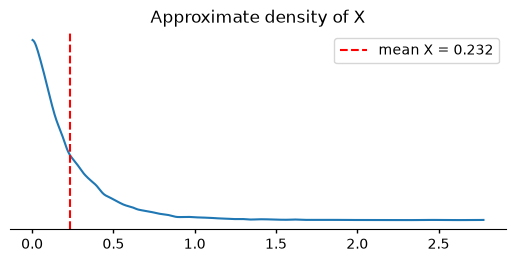

In [237]:
rng = np.random.default_rng()

def get_processing_time(rate : float) :
  return rng.exponential(1 / rate)
def expected_processing_time(Rates) :
  S = sum(Rates)
  barber = rng.choice(range(len(Rates)), p = [r / S for r in Rates])
  return get_processing_time(Rates[barber])

samples = np.array([expected_processing_time([3, 6, 4]) for _ in range(10000)])
mean_X = np.mean(samples)
std_X = np.std(samples)
print(mean_X)
print(std_X)

samples_dt = arviz.from_dict({'posterior': {'X': samples[None, :]}})
arviz.plot_dist(samples_dt, kind='kde', visuals={'credible_interval': False, 'point_estimate': False, 'point_estimate_text': False})
ax = plt.gca()
ax.axvline(mean_X, color='red', linestyle='--', label=f"mean X = {mean_X:.3f}")
ax.set_title("Approximate density of X")
ax.legend()
plt.show()